# Closed-loop calibration of one faulty encoding gate

The faulty CNOT contributes a hidden `Rx(epsilon)`. We add `Rx(-theta)`, leaving $R_x(\epsilon-\theta)$. The search chooses `theta` using only sampled syndrome counts.

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit.visualization import plot_histogram

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qec_calibration import (
    build_compensated_syndrome_circuit,
    calibrate_single_gate,
    run_compensated_syndrome,
    theoretical_compensated_loss,
)

TRUE_ERROR = 0.20
SEARCH_BOUNDS = (-0.4, 0.4)
LEVELS = 3
POINTS_PER_LEVEL = 9
SHOTS_PER_POINT = 1024
VALIDATION_SHOTS = 1024
SEED = 42

## 1. Compensation circuit

The explicit `Rx(-theta)` follows `cx(0, 1)`. The coherent error remains in the Aer noise model, so it is not visible in the drawing.

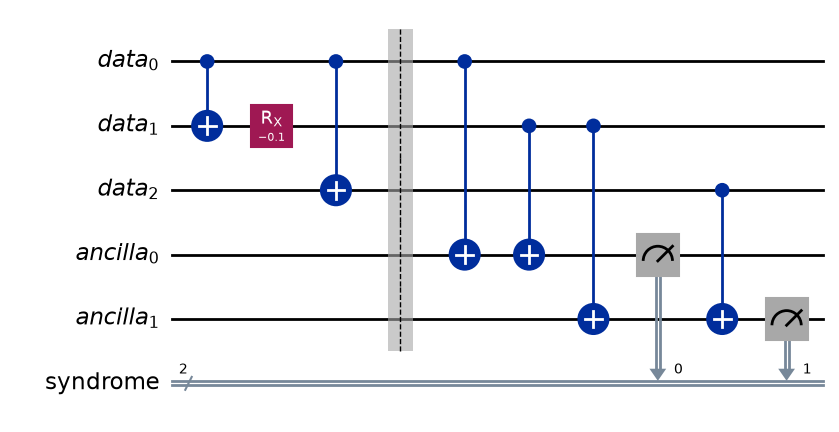

In [11]:
trial_circuit = build_compensated_syndrome_circuit(0.10)
trial_circuit.draw(output="mpl", fold=-1)

## 2. Measured objective

We minimize $L(\theta)=1-\widehat{P}(00)$. Here this equals $\widehat{P}(11)$, with exact landscape $\sin^2((\epsilon-\theta)/2)$.

In [12]:
initial_counts = run_compensated_syndrome(TRUE_ERROR, 0.0, shots=VALIDATION_SHOTS, seed=SEED)
print("Initial counts:", initial_counts)
print("Initial theoretical loss:", theoretical_compensated_loss(TRUE_ERROR, 0.0))

Initial counts: {'11': 10, '00': 1014}
Initial theoretical loss: 0.009966711079379185


## 3. Coarse-to-fine calibration

Each level evaluates nine angles, selects the smallest sampled syndrome rate, and narrows the next range. Tied zero-count trials are averaged.

In [13]:
result = calibrate_single_gate(
    true_error=TRUE_ERROR,
    search_bounds=SEARCH_BOUNDS,
    levels=LEVELS,
    points_per_level=POINTS_PER_LEVEL,
    shots_per_point=SHOTS_PER_POINT,
    validation_shots=VALIDATION_SHOTS,
    seed=SEED,
)
history = pd.DataFrame(result.evaluations)
level_summary = pd.DataFrame(result.level_summaries)
level_summary

,level,lower_bound,upper_bound,grid_spacing,minimum_measured_loss,level_estimate,tied_minima
0,1,-0.4000,0.4000,0.10000,0.0,0.2000,1
1,2,0.1000,0.3000,0.02500,0.0,0.1875,4
2,3,0.1625,0.2125,0.00625,0.0,0.1875,7


In [14]:
print(f"Hidden error angle:      {result.true_error:+.6f} rad")
print(f"Estimated correction:   {result.estimated_correction:+.6f} rad")
print(f"Remaining residual:      {result.residual_angle:+.6f} rad")
print(f"Initial expected loss:   {result.initial_theoretical_loss:.6f}")
print(f"Validated measured loss: {result.validation_loss:.6f}")
print("Validation counts:", result.validation_counts)

Hidden error angle:      +0.200000 rad
Estimated correction:   +0.187500 rad
Remaining residual:      +0.012500 rad
Initial expected loss:   0.009967
Validated measured loss: 0.000000
Validation counts: {'00': 1024}


## 4. Search landscape

The analytic curve is shown only as a diagnostic; the search receives sampled counts alone.

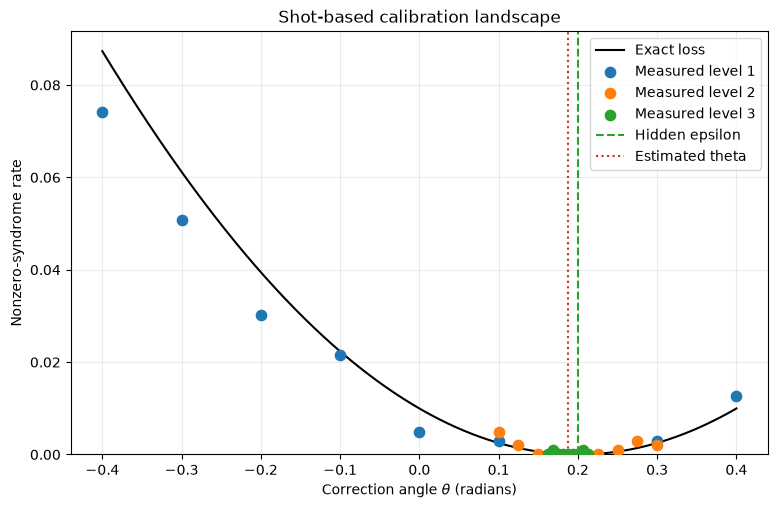

In [15]:
theta_curve = np.linspace(*SEARCH_BOUNDS, 500)
theory_curve = [theoretical_compensated_loss(TRUE_ERROR, theta) for theta in theta_curve]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(theta_curve, theory_curve, color="black", label="Exact loss")
for level, rows in history.groupby("level"):
    ax.scatter(rows["correction_angle"], rows["measured_loss"], s=55, label=f"Measured level {level}", zorder=3)
ax.axvline(TRUE_ERROR, color="tab:green", linestyle="--", label="Hidden epsilon")
ax.axvline(result.estimated_correction, color="tab:red", linestyle=":", label="Estimated theta")
ax.set(xlabel=r"Correction angle $\theta$ (radians)", ylabel="Nonzero-syndrome rate", title="Shot-based calibration landscape")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 5. Convergence and before/after syndromes

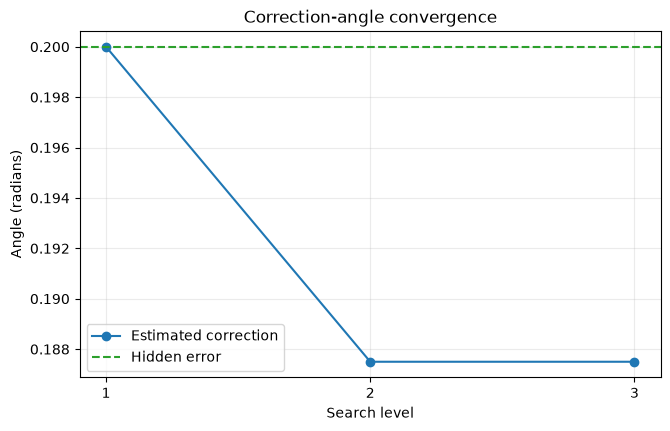

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(level_summary["level"], level_summary["level_estimate"], marker="o", label="Estimated correction")
ax.axhline(TRUE_ERROR, color="tab:green", linestyle="--", label="Hidden error")
ax.set(xlabel="Search level", ylabel="Angle (radians)", title="Correction-angle convergence", xticks=level_summary["level"])
ax.grid(alpha=0.25)
ax.legend()
plt.show()

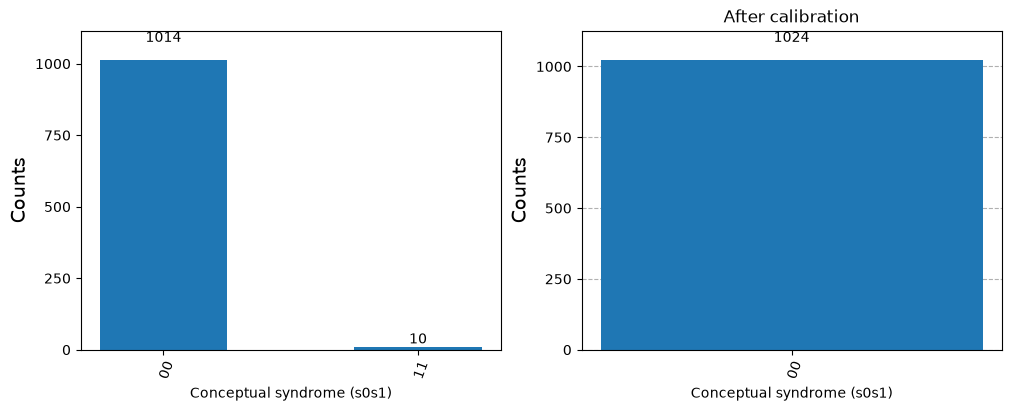

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
plot_histogram(initial_counts, ax=axes[0], title="Before calibration")
plot_histogram(result.validation_counts, ax=axes[1], title="After calibration")
for ax in axes:
    ax.set_xlabel("Conceptual syndrome (s0s1)")
    ax.set_ylabel("Counts")
plt.show()

## 6. Validation

In [18]:
assert abs(result.estimated_correction - TRUE_ERROR) <= 0.05
assert result.validation_loss < result.initial_theoretical_loss
assert len(result.evaluations) == LEVELS * POINTS_PER_LEVEL
print("Single-gate closed-loop calibration: PASS")

Single-gate closed-loop calibration: PASS


## Interpretation

The syndrome supplies an experimental cost function without directly revealing the gate angle. Finite shots limit precision near the minimum; increasing shots lowers that statistical floor.